# RQ1: Baseline correlation

**To what extent do LLM-generated beliefs correlate with human World Values Survey responses overall?**



1.   Compute Pearson correlation between human WVS means and LLM answers
2.   Compute Mean Absolute Error (MAE)
3.   Compute p-value for significance

# 1.0 Setting file paths and options

In [1]:
# Core libraries for data handling and statistics
import json
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from scipy import stats
from scipy.stats import norm
from IPython.display import display

import networkx as nx
from collections import Counter
from itertools import combinations

# ── INPUT FILES ──────────────────────────────────────────────────────────────
# NOTE:
# Update these paths if your JSON files are stored in a different location.
# By default, the notebook expects the files to be in the same folder
# as the notebook itself.
BASE_DIR = Path.cwd()

LLM_RESULTS_PATH = BASE_DIR / "wvs_results_openai_keywords.json" # Update this if analyzing a different model (to either "wvs_results_mistral_keywords.json" or "wvs_results_glm_keywords.json")
HUMAN_MEANS_PATH = BASE_DIR / "wvs_normalized_means.json"

MODEL_NAME = "GPT-5.1"  # Update this if analyzing a different model (to either "Mistral Large 3" or "GLM-5")

# ── QUESTION DOMAINS ─────────────────────────────────────────────────────────
DOMAIN_QUESTIONS = {
    'Economic':  [f'Q{i}' for i in range(106, 112)],
    'Religious': [f'Q{i}' for i in range(164, 176)],
    'Ethical':   [f'Q{i}' for i in range(176, 199)]
}

# Load JSON input files
with open(LLM_RESULTS_PATH, 'r') as f:
    llm_results = json.load(f)

with open(HUMAN_MEANS_PATH, 'r') as f:
    human_means = json.load(f)

# Collect region and question metadata
regions = list(llm_results.keys())

all_questions = [
    q for domain_qs in DOMAIN_QUESTIONS.values()
    for q in domain_qs
]

print(f"Regions loaded:     {len(regions)}")
print(f"Questions included: {len(all_questions)}")
print(f"Total pairs:        {len(regions) * len(all_questions)}")
print(f"Regions: {regions}")


Regions loaded:     8
Questions included: 41
Total pairs:        328
Regions: ['Orthodox_Europe', 'African-Islamic', 'Latin_America', 'West_and_South_Asia', 'Confucian', 'Catholic_Europe', 'Protestant_Europe', 'English-speaking']


## 1.1 Normalize LLM results to 0-1 scale

The WVS data (human means) are on a 0-1 scale. The raw LLM answers, however, are on different scales for different questions. To make them comparable, we need to normalize the LLM answers to a 0-1 scale based on their original question-specific ranges.

In [2]:
# Define the scaling rules for each question range
SCALING_RULES = {
    'Q106-Q110': {'min': 1, 'max': 10, 'questions': [f'Q{i}' for i in range(106, 111)]},
    'Q111':      {'min': 1, 'max': 2,  'questions': ['Q111']},
    'Q164':      {'min': 1, 'max': 10, 'questions': ['Q164']},
    'Q165-Q168': {'min': 1, 'max': 2,  'questions': [f'Q{i}' for i in range(165, 169)]},
    'Q169-Q170': {'min': 1, 'max': 4,  'questions': [f'Q{i}' for i in range(169, 171)]},
    'Q171':      {'min': 1, 'max': 7,  'questions': ['Q171']},
    'Q172':      {'min': 1, 'max': 8,  'questions': ['Q172']},
    'Q173':      {'min': 1, 'max': 3,  'questions': ['Q173']},
    'Q174-Q175': {'min': 1, 'max': 2,  'questions': [f'Q{i}' for i in range(174, 176)]},
    'Q176-Q195': {'min': 1, 'max': 10, 'questions': [f'Q{i}' for i in range(176, 196)]},
    'Q196-Q198': {'min': 1, 'max': 4,  'questions': [f'Q{i}' for i in range(196, 199)]}
}

# Create a mapping from question ID to its min/max values
question_min_max = {}
for rule_name, rule_data in SCALING_RULES.items():
    for q_id in rule_data['questions']:
        question_min_max[q_id] = {'min': rule_data['min'], 'max': rule_data['max']}

# Function to apply min-max scaling for a 0-1 range
def normalize_to_0_1(value, q_id):
    if q_id not in question_min_max:
        return np.nan # Or handle unknown questions as appropriate

    q_min = question_min_max[q_id]['min']
    q_max = question_min_max[q_id]['max']

    if q_max == q_min:
        return 0.0 # Avoid division by zero if min and max are the same

    return (float(value) - q_min) / (q_max - q_min)

# Normalize llm_results in-place
for region in llm_results:
    for q_id in llm_results[region]:
        val = llm_results[region][q_id]
        
        # Handle keywords format {"answer": ..., "keywords": ...}
        if isinstance(val, dict):
            val = val.get("answer")
        
        if val is not None:
            try:
                llm_results[region][q_id] = normalize_to_0_1(val, q_id)
            except (ValueError, TypeError):
                llm_results[region][q_id] = np.nan
        else:
            llm_results[region][q_id] = np.nan

print(f"{MODEL_NAME} values normalized to 0-1 scale within llm_results dictionary.")

# Check for NaN values after normalization
nan_count = 0
nan_list = []

for region in llm_results:
    for q_id in llm_results[region]:
        val = llm_results[region][q_id]
        if val is None or (isinstance(val, float) and np.isnan(val)):
            nan_count += 1
            nan_list.append({'region': region, 'question': q_id})

print(f"Total NaN values: {nan_count} / {len(regions) * len(all_questions)}")

if nan_list:
    print("\nAffected region-question pairs:")
    for item in nan_list:
        print(f"  {item['region']} — {item['question']}")
else:
    print("No NaN values found")

GPT-5.1 values normalized to 0-1 scale within llm_results dictionary.
Total NaN values: 0 / 328
No NaN values found


## 1.2 Build paired vectors

In [3]:
# Analysis step
records = []

for region in regions:
    for q_id in all_questions:
        # Get LLM answer
        llm_val = llm_results.get(region, {}).get(q_id)
        # Get human mean
        human_val = human_means.get(region, {}).get(q_id)

        if llm_val is None or human_val is None or (isinstance(llm_val, float) and np.isnan(llm_val)):
            continue

        try:
            llm_val   = float(llm_val)
            human_val = float(human_val)
        except (ValueError, TypeError):
            continue

        # Determine domain
        domain = next((d for d, qs in DOMAIN_QUESTIONS.items() if q_id in qs), 'Unknown')

        records.append({
            'region':    region,
            'question':  q_id,
            'domain':    domain,
            'llm':       llm_val,
            'human':     human_val,
            'abs_error': abs(llm_val - human_val)
        })

df = pd.DataFrame(records)
print(f"Valid pairs: {len(df)} / {len(regions) * len(all_questions)}")
df.head()

Valid pairs: 328 / 328


,region,question,domain,llm,human,abs_error
0,Orthodox_Europe,Q106,Economic,0.222222,0.650795,0.428573
1,Orthodox_Europe,Q107,Economic,0.333333,0.550026,0.216693
2,Orthodox_Europe,Q108,Economic,0.333333,0.383533,0.050200
3,Orthodox_Europe,Q109,Economic,0.555556,0.309072,0.246483
4,Orthodox_Europe,Q110,Economic,0.333333,0.409197,0.075863


## 1.3 Compute overall Pearson correlation, MAE and p-value

In [4]:
def pearson_ci(r, n, confidence=0.95):
    """Compute confidence interval for Pearson r using Fisher z-transformation."""
    z = np.arctanh(r)  # Fisher z-transform
    se = 1 / np.sqrt(n - 3)  # standard error
    z_crit = stats.norm.ppf((1 + confidence) / 2)  # critical value
    z_low  = z - z_crit * se
    z_high = z + z_crit * se
    # Transform back to r scale
    return np.tanh(z_low), np.tanh(z_high)

# Analysis step
r, p_value = stats.pearsonr(df['human'], df['llm'])
mae        = df['abs_error'].mean()
n          = len(df)
ci_low, ci_high = pearson_ci(r, len(df))

print(f"Model:       {MODEL_NAME}")
print(f"N pairs:     {n}")
print(f"Pearson r:   {r:.3f}")
print(f"95% CI:      ({ci_low:.3f}, {ci_high:.3f})")
print(f"p-value:     {p_value}  {'*** (p < 0.001)' if p_value < 0.001 else '** (p < 0.01)' if p_value < 0.01 else '* (p < 0.05)' if p_value < 0.05 else '(not significant)'}")
print(f"MAE:         {mae:.3f}  (on normalized scale 0-1)")

Model:       GPT-5.1
N pairs:     328
Pearson r:   0.737
95% CI:      (0.684, 0.783)
p-value:     1.641256491227311e-57  *** (p < 0.001)
MAE:         0.169  (on normalized scale 0-1)


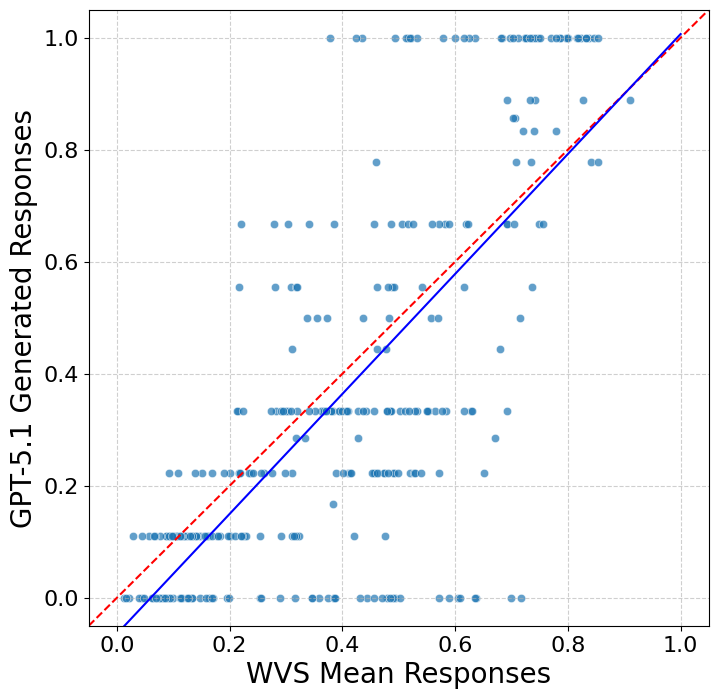

In [5]:
# Plot scatterplot of human vs LLM responses
plt.figure(figsize=(8, 8))
sns.scatterplot(x='human', y='llm', data=df, alpha=0.7)
plt.xlabel('WVS Mean Responses', fontsize=20)
plt.ylabel(f'{MODEL_NAME} Generated Responses', fontsize=20)
plt.xticks(fontsize=16)
plt.yticks(fontsize=16)
plt.grid(True, linestyle='--', alpha=0.6)
plt.axline((0, 0), slope=1, color='red', linestyle='--')
m, b = np.polyfit(df['human'], df['llm'], 1)
plt.plot(np.linspace(0, 1, 100), m * np.linspace(0, 1, 100) + b,
         color='blue', linewidth=1.5)
plt.xlim(-0.05, 1.05)
plt.ylim(-0.05, 1.05)
plt.show()

# RQ2: Variation across cultural regions

**How does the correlation between LLM-generated beliefs and human World Values Survey responses vary across the Inglehart-Welzel cultural regions?**

## 2.1 Compute Pearson correlation for each region

In [6]:
region_correlations = []

for region in regions:
    df_region = df[df['region'] == region]
    if len(df_region) > 1:
        r_region, p_value_region = stats.pearsonr(df_region['human'], df_region['llm'])
        mae_region = df_region['abs_error'].mean()
        ci_low, ci_high = pearson_ci(r_region, len(df_region))

        region_correlations.append({
            'region':    region,
            'n_pairs':   len(df_region),
            'pearson_r': r_region,
            'ci_low':    ci_low,
            'ci_high':   ci_high,
            'p_value':   p_value_region,
            'mae':       mae_region
        })

region_correlations_df = pd.DataFrame(region_correlations)
print("Correlations per region (with 95% CI):")
display(region_correlations_df)

Correlations per region (with 95% CI):


,region,n_pairs,pearson_r,ci_low,ci_high,p_value,mae
0,Orthodox_Europe,41,0.755395,0.583303,0.862583,1.143340e-08,0.145634
1,African-Islamic,41,0.721376,0.531734,0.842131,1.031860e-07,0.138708
2,Latin_America,41,0.795906,0.646577,0.886490,4.977881e-10,0.164813
3,West_and_South_Asia,41,0.675078,0.463741,0.813727,1.290529e-06,0.181164
4,Confucian,41,0.671919,0.459191,0.811765,1.508538e-06,0.164724
5,Catholic_Europe,41,0.664386,0.448384,0.807072,2.172733e-06,0.225229
6,Protestant_Europe,41,0.798092,0.650051,0.887766,4.121449e-10,0.159660
7,English-speaking,41,0.837801,0.714247,0.910715,8.430649e-12,0.174866


## 2.2 Fisher's z-transformation and significance testing

Using the Fisher's z-transformation to compute significant differences between the correlations from the different cultural regions

In [7]:
from scipy.stats import norm

def r_to_z(r):
    return 0.5 * np.log((1 + r) / (1 - r))

def z_to_r(z):
    return (np.exp(2 * z) - 1) / (np.exp(2 * z) + 1)

# Convert Pearson r values to z-scores
region_correlations_df['z_score'] = region_correlations_df['pearson_r'].apply(r_to_z)

# Calculate standard error for each z-score
# SE_z = 1 / sqrt(n - 3)
region_correlations_df['se_z'] = 1 / np.sqrt(region_correlations_df['n_pairs'] - 3)

print("Region correlations with z-scores and standard errors:")
display(region_correlations_df)

# Perform significance tests between all pairs of regions
print("\nPairwise Fisher's z-test for difference in correlations:")
results = []
for i in range(len(region_correlations_df)):
    for j in range(i + 1, len(region_correlations_df)):
        region1 = region_correlations_df.iloc[i]
        region2 = region_correlations_df.iloc[j]

        # Difference in z-scores
        diff_z = region1['z_score'] - region2['z_score']

        # Standard error of the difference
        se_diff_z = np.sqrt(region1['se_z']**2 + region2['se_z']**2)

        # Z-statistic
        z_stat = diff_z / se_diff_z

        # Two-tailed p-value
        p_val = 2 * (1 - norm.cdf(abs(z_stat)))

        results.append({
            'region1': region1['region'],
            'region2': region2['region'],
            'pearson_r1': region1['pearson_r'],
            'pearson_r2': region2['pearson_r'],
            'z_stat': z_stat,
            'p_value': p_val,
            'significant': p_val < 0.05
        })

pairwise_test_df = pd.DataFrame(results)
display(pairwise_test_df)

Region correlations with z-scores and standard errors:


,region,n_pairs,pearson_r,ci_low,ci_high,p_value,mae,z_score,se_z
0,Orthodox_Europe,41,0.755395,0.583303,0.862583,1.143340e-08,0.145634,0.985403,0.162221
1,African-Islamic,41,0.721376,0.531734,0.842131,1.031860e-07,0.138708,0.910507,0.162221
2,Latin_America,41,0.795906,0.646577,0.886490,4.977881e-10,0.164813,1.087342,0.162221
3,West_and_South_Asia,41,0.675078,0.463741,0.813727,1.290529e-06,0.181164,0.820015,0.162221
4,Confucian,41,0.671919,0.459191,0.811765,1.508538e-06,0.164724,0.814234,0.162221
5,Catholic_Europe,41,0.664386,0.448384,0.807072,2.172733e-06,0.225229,0.800624,0.162221
6,Protestant_Europe,41,0.798092,0.650051,0.887766,4.121449e-10,0.159660,1.093334,0.162221
7,English-speaking,41,0.837801,0.714247,0.910715,8.430649e-12,0.174866,1.213750,0.162221



Pairwise Fisher's z-test for difference in correlations:


,region1,region2,pearson_r1,pearson_r2,z_stat,p_value,significant
0,Orthodox_Europe,African-Islamic,0.755395,0.721376,0.326463,0.744074,False
1,Orthodox_Europe,Latin_America,0.755395,0.795906,-0.444343,0.656794,False
2,Orthodox_Europe,West_and_South_Asia,0.755395,0.675078,0.720908,0.470966,False
3,Orthodox_Europe,Confucian,0.755395,0.671919,0.746107,0.455603,False
4,Orthodox_Europe,Catholic_Europe,0.755395,0.664386,0.805431,0.420571,False
5,Orthodox_Europe,Protestant_Europe,0.755395,0.798092,-0.470463,0.638025,False
6,Orthodox_Europe,English-speaking,0.755395,0.837801,-0.995341,0.319570,False
7,African-Islamic,Latin_America,0.721376,0.795906,-0.770806,0.440822,False
8,African-Islamic,West_and_South_Asia,0.721376,0.675078,0.394446,0.693252,False
9,African-Islamic,Confucian,0.721376,0.671919,0.419644,0.674745,False


## 2.3 Rank regions by alignment

In [8]:
# Ranking by Pearson r (higher is better alignment)
ranked_by_r = region_correlations_df.sort_values(by='pearson_r', ascending=False).reset_index(drop=True)
print("Regions ranked by Pearson r:")
display(ranked_by_r[['region', 'pearson_r', 'mae']])

# Ranking by MAE (lower is better alignment)
ranked_by_mae = region_correlations_df.sort_values(by='mae', ascending=True).reset_index(drop=True)
print("\nRegions ranked by MAE:")
display(ranked_by_mae[['region', 'pearson_r', 'mae']])

Regions ranked by Pearson r:


,region,pearson_r,mae
0,English-speaking,0.837801,0.174866
1,Protestant_Europe,0.798092,0.159660
2,Latin_America,0.795906,0.164813
3,Orthodox_Europe,0.755395,0.145634
4,African-Islamic,0.721376,0.138708
5,West_and_South_Asia,0.675078,0.181164
6,Confucian,0.671919,0.164724
7,Catholic_Europe,0.664386,0.225229



Regions ranked by MAE:


,region,pearson_r,mae
0,African-Islamic,0.721376,0.138708
1,Orthodox_Europe,0.755395,0.145634
2,Protestant_Europe,0.798092,0.159660
3,Confucian,0.671919,0.164724
4,Latin_America,0.795906,0.164813
5,English-speaking,0.837801,0.174866
6,West_and_South_Asia,0.675078,0.181164
7,Catholic_Europe,0.664386,0.225229


# RQ3: Variation across value domains

**How does the correlation between LLM-generated beliefs and human World Values Survey responses vary across different value domains, and does this vary across cultural regions?**

1. Compute Pearson correlation per domain and cultural region
2. Compare variation between domains using Fisher's z-transformation

## 3.1 Compute Pearson correlation, MAE and 95% CI per domain and region

In [9]:
domain_region_results = []

for region in regions:
    for domain in DOMAIN_QUESTIONS.keys():
        subset = df[(df['region'] == region) & (df['domain'] == domain)]
        if len(subset) < 3:
            continue

        r, p            = stats.pearsonr(subset['human'], subset['llm'])
        mae             = subset['abs_error'].mean()
        ci_low, ci_high = pearson_ci(r, len(subset))

        domain_region_results.append({
            'region':    region,
            'domain':    domain,
            'n_pairs':   len(subset),
            'pearson_r': round(r, 3),
            'ci_low':    round(ci_low, 3),
            'ci_high':   round(ci_high, 3),
            'p_value':   round(p, 4),
            'mae':       round(mae, 3)
        })

domain_region_df = pd.DataFrame(domain_region_results)
print(f"Correlation per domain per region ({MODEL_NAME}):")
display(domain_region_df)

Correlation per domain per region (GPT-5.1):


,region,domain,n_pairs,pearson_r,ci_low,ci_high,p_value,mae
0,Orthodox_Europe,Economic,6,-0.573,-0.945,0.446,0.2349,0.252
1,Orthodox_Europe,Religious,12,0.819,0.463,0.948,0.0011,0.220
2,Orthodox_Europe,Ethical,23,0.894,0.764,0.955,0.0000,0.079
3,African-Islamic,Economic,6,-0.391,-0.913,0.616,0.4428,0.224
4,African-Islamic,Religious,12,0.807,0.434,0.944,0.0015,0.217
5,African-Islamic,Ethical,23,0.831,0.637,0.926,0.0000,0.076
6,Latin_America,Economic,6,0.276,-0.690,0.889,0.5961,0.200
7,Latin_America,Religious,12,0.839,0.512,0.954,0.0006,0.218
8,Latin_America,Ethical,23,0.868,0.710,0.943,0.0000,0.128
9,West_and_South_Asia,Economic,6,0.333,-0.656,0.901,0.5185,0.181


## 3.2 Fisher z-tests: pairwise domain comparisons

In [10]:
from itertools import combinations
from scipy.stats import wilcoxon

# Wilcoxon signed-rank tests comparing domain correlations across regions
wilcoxon_domain_results = []

# list of unique domains present in the domain_region_df
all_domains = sorted(domain_region_df['domain'].unique())

# For each pair of domains, collect paired Pearson r values across regions
for d1, d2 in combinations(all_domains, 2):
    paired = []
    for region in domain_region_df['region'].unique():
        r1_row = domain_region_df[(domain_region_df['region'] == region) & (domain_region_df['domain'] == d1)]
        r2_row = domain_region_df[(domain_region_df['region'] == region) & (domain_region_df['domain'] == d2)]
        if len(r1_row) == 1 and len(r2_row) == 1:
            paired.append((r1_row.iloc[0]['pearson_r'], r2_row.iloc[0]['pearson_r']))

    n_pairs = len(paired)

    # Skip comparisons with too few paired observations
    if n_pairs < 3:
        wilcoxon_domain_results.append({
            'domain_1': d1,
            'domain_2': d2,
            'n_pairs': n_pairs,
            'statistic': None,
            'p_value': None,
            'median_diff': None,
            'significant': 'Too few pairs (n<3)'
        })
        continue

    r1_vals = [p[0] for p in paired]
    r2_vals = [p[1] for p in paired]

    # Perform Wilcoxon signed-rank test on paired domain correlations across regions
    try:
        stat, p_val = wilcoxon(r1_vals, r2_vals, alternative='two-sided', zero_method='wilcox')
    except Exception:
        stat, p_val = None, None

    median_diff = float(np.median(np.array(r1_vals) - np.array(r2_vals)))

    wilcoxon_domain_results.append({
        'domain_1': d1,
        'domain_2': d2,
        'n_pairs': n_pairs,
        'statistic': stat,
        'p_value': p_val,
        'median_diff': median_diff,
        'significant': 'Yes' if (p_val is not None and p_val < 0.05) else 'No',
    })

wilcoxon_domain_df = pd.DataFrame(wilcoxon_domain_results)
print('Wilcoxon signed-rank test: pairwise domain comparisons across regions')
display(wilcoxon_domain_df)

Wilcoxon signed-rank test: pairwise domain comparisons across regions


,domain_1,domain_2,n_pairs,statistic,p_value,median_diff,significant
0,Economic,Ethical,8,0.0,0.007812,-0.5595,Yes
1,Economic,Religious,8,3.0,0.039062,-0.3545,Yes
2,Ethical,Religious,8,4.0,0.054688,0.1840,No


## 3.3 Heatmap: correlation per domain per region

Plot the Pearson correlation coefficients per cultural region and value domain in a heatmap

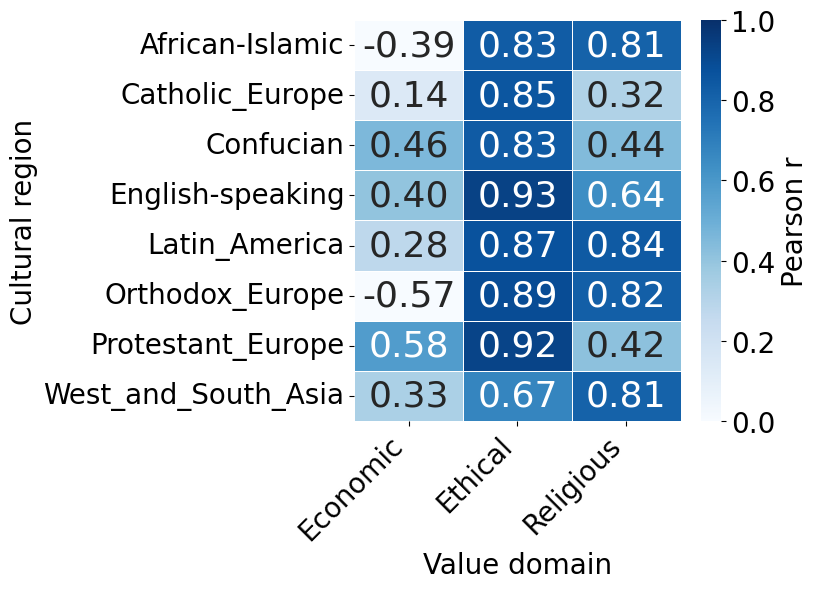

In [11]:
import seaborn as sns
import matplotlib.pyplot as plt

pivot = domain_region_df.pivot(index='region', columns='domain', values='pearson_r')

fig, ax = plt.subplots(figsize=(8, 6))
sns.heatmap(pivot, annot=True, fmt='.2f', cmap=sns.color_palette("Blues", as_cmap=True),
            vmin=0, vmax=1, linewidths=0.5,
            ax=ax, annot_kws={'fontsize': 26})

ax.set_xlabel('Value domain', fontsize=20)
ax.set_ylabel('Cultural region', fontsize=20)

ax.tick_params(axis='x', labelsize=20)
ax.tick_params(axis='y', labelsize=20)
ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right')

cbar = ax.collections[0].colorbar
cbar.set_label('Pearson r', fontsize=20)
cbar.ax.tick_params(labelsize=20)

plt.tight_layout()
plt.show()

# RQ4: Reasoning keywords analysis

**How do the reasoning patterns generated by LLMs differ between high- and low-correlation cultural regions within each value domain and across different models?**

1. Divide the two highest and lowest correlation cultural regions into groups
2. Make keyword co-occurrence networks for both groups
3. Compute network degree and density statistics

## 4.1 Dividing two highest and lowest correlation cultural regions into groups

In [12]:
# Dictionary to store low- and high-correlation region groups for each domain
domain_groups = {}

# Process each domain separately
for domain in domain_region_df['domain'].unique():

    # Select only rows belonging to the current domain
    df_domain = domain_region_df[
        domain_region_df['domain'] == domain
    ].copy()

    # Require a minimum number of region-domain observations
    # to make quartile-based grouping meaningful
    if len(df_domain) < 4:
        print(f"Skipping {domain}: too few region-domain pairs")
        continue

    # Calculate the 25th and 75th percentile Pearson correlations
    # within the current domain
    q1 = df_domain['pearson_r'].quantile(0.25)
    q4 = df_domain['pearson_r'].quantile(0.75)

    # Regions in the lowest quartile of correlations
    low = df_domain[df_domain['pearson_r'] <= q1]

    # Regions in the highest quartile of correlations
    high = df_domain[df_domain['pearson_r'] >= q4]

    # Skip domains where one of the groups is empty
    if len(low) == 0 or len(high) == 0:
        print(f"Skipping {domain}: empty low/high group")
        continue

    # Store the low- and high-correlation groups
    # for later comparative analysis
    domain_groups[domain] = {
        'low': low,
        'high': high
    }

    # Display summary information for verification
    print(f"\n{domain}")
    print(f"Low threshold:  {q1:.3f}")
    print(f"High threshold: {q4:.3f}")
    print(f"Low count:  {len(low)}")
    print(f"High count: {len(high)}")


Economic
Low threshold:  0.007
High threshold: 0.416
Low count:  2
High count: 2

Religious
Low threshold:  0.437
High threshold: 0.811
Low count:  2
High count: 2

Ethical
Low threshold:  0.833
High threshold: 0.901
Low count:  2
High count: 2


## 4.2 Compute the keyword co-occurrence networks

Only keywords occurring two or more times get an edge and are vizualized

In [18]:
# -----------------------------
# 1. Keyword extraction
# -----------------------------

def extract_keywords(domain_region_pairs, llm_keywords_raw, DOMAIN_QUESTIONS):
    """
    Extract all LLM-generated keywords associated with the
    domain-region pairs included in the analysis.
    """
    keywords = []

    for _, row in domain_region_pairs.iterrows():
        region = row['region']
        domain = row['domain']
        questions = DOMAIN_QUESTIONS[domain]

        # Collect keywords from all questions belonging to the domain
        for q_id in questions:
            val = llm_keywords_raw.get(region, {}).get(q_id)

            if isinstance(val, dict) and val.get('keywords'):
                kws = [k.strip() for k in val['keywords'].split(',')]
                keywords.extend(kws)

    return keywords


# -----------------------------
# 2. Build graph
# -----------------------------

def build_graph(domain_region_pairs, llm_keywords_raw, keywords_list, DOMAIN_QUESTIONS):

    keyword_domain_counts = {}
    cooccurrence = Counter()

    # Build keyword-domain frequencies and keyword co-occurrence counts
    for _, row in domain_region_pairs.iterrows():
        region = row['region']
        domain = row['domain']
        questions = DOMAIN_QUESTIONS[domain]

        for q_id in questions:
            val = llm_keywords_raw.get(region, {}).get(q_id)

            if isinstance(val, dict) and val.get('keywords'):
                kws = [k.strip() for k in val['keywords'].split(',')]

                # Track how often each keyword appears within a domain
                for kw in kws:
                    if kw not in keyword_domain_counts:
                        keyword_domain_counts[kw] = Counter()
                    keyword_domain_counts[kw][domain] += 1

                # Count keyword co-occurrences within the same response
                for kw1, kw2 in combinations(set(kws), 2):
                    cooccurrence[tuple(sorted((kw1, kw2)))] += 1

    # Overall keyword frequencies across all observations
    keyword_freq = Counter(keywords_list)

    G = nx.Graph()

    # Node size later reflects keyword frequency
    for kw, freq in keyword_freq.items():
        G.add_node(kw, freq=freq)

    # Only retain relationships observed multiple times
    MIN_COOCCURRENCE = 2

    for (kw1, kw2), w in cooccurrence.items():
        if w >= MIN_COOCCURRENCE:
            G.add_edge(kw1, kw2, weight=w)

    # Remove keywords that have no connections
    G.remove_nodes_from(list(nx.isolates(G)))

    return G, keyword_domain_counts, keyword_freq


# -----------------------------
# 3. Metrics
# -----------------------------

def compute_metrics(G):

    if len(G) == 0:
        return None

    # Weighted degree incorporates edge strength (co-occurrence frequency)
    weighted_degree = dict(G.degree(weight="weight"))

    degree = dict(G.degree())

    # Basic network cohesion measures
    avg_degree = sum(degree.values()) / len(degree) if degree else 0
    density = nx.density(G)

    return {
        "num_nodes": G.number_of_nodes(),
        "num_edges": G.number_of_edges(),
        "avg_degree": avg_degree,
        "density": density
    }


# -----------------------------
# 4. Keyword frequency analysis
# -----------------------------

def keyword_frequency_analysis(keyword_freq, top_n=10):

    total = sum(keyword_freq.values())

    return {
        "num_unique_keywords": len(keyword_freq),
        "total_keyword_mentions": total,
        "top_keywords": keyword_freq.most_common(top_n)
    }


# -----------------------------
# 5. Full pipeline per graph
# -----------------------------

def analyze_graph(domain_region_pairs, llm_keywords_raw, DOMAIN_QUESTIONS):
    """
    Run the complete keyword-network analysis workflow
    for a single group of domain-region pairs.
    """
    keywords = extract_keywords(
        domain_region_pairs,
        llm_keywords_raw,
        DOMAIN_QUESTIONS
    )

    G, kw_domain_counts, kw_freq = build_graph(
        domain_region_pairs,
        llm_keywords_raw,
        keywords,
        DOMAIN_QUESTIONS
    )

    metrics = compute_metrics(G)
    keyword_freq = keyword_frequency_analysis(kw_freq)

    return {
        "graph": G,
        "metrics": metrics,
        "keyword_frequency": keyword_freq
    }


# -----------------------------
# 6. Run for all domains/groups
# -----------------------------

def run_all(domain_groups, llm_keywords_raw, DOMAIN_QUESTIONS):

    results = {}

    for domain, groups in domain_groups.items():

        print(f"\n===== {domain} =====")

        # Compare low-correlation and high-correlation region groups
        low_result = analyze_graph(
            groups['low'],
            llm_keywords_raw,
            DOMAIN_QUESTIONS
        )

        high_result = analyze_graph(
            groups['high'],
            llm_keywords_raw,
            DOMAIN_QUESTIONS
        )

        results[domain] = {
            "low": low_result,
            "high": high_result
        }

        print("Low:", low_result["metrics"])
        print("High:", high_result["metrics"])

    return results


# -----------------------------
# 7. Visualization
# -----------------------------

def plot_graph(G, node_color="#378ADD", adjustments=None):

    if len(G.nodes()) == 0:
        print("Graph is empty.")
        return

    plt.figure(figsize=(14, 10))

    # Force-directed layout for keyword networks
    pos = nx.spring_layout(G, seed=42, k=1)

    # Optional manual label/node adjustments to improve readability
    if adjustments:
        for node, (dx, dy) in adjustments.items():
            if node in pos:
                pos[node][0] += dx
                pos[node][1] += dy

    # Node size represents keyword frequency
    node_sizes = [
        200 + 200 * G.nodes[node].get("freq", 1)
        for node in G.nodes()
    ]

    # Edge width represents co-occurrence strength
    edge_weights = [
        G[u][v]["weight"]
        for u, v in G.edges()
    ]

    max_w = max(edge_weights) if edge_weights else 1

    edge_widths = [
        1 + 15 * (w / max_w)
        for w in edge_weights
    ]

    nx.draw_networkx_edges(
        G,
        pos,
        width=edge_widths,
        alpha=0.3,
        edge_color="black"
    )

    nx.draw_networkx_nodes(
        G,
        pos,
        node_size=node_sizes,
        node_color=node_color,
        alpha=0.9
    )

    # Offset labels slightly above nodes to reduce overlap
    label_pos = {
        node: (x, y + 0.1)
        for node, (x, y) in pos.items()
    }

    nx.draw_networkx_labels(
        G,
        label_pos,
        font_size=20
    )

    plt.axis("off")
    plt.tight_layout()

    # Add margins to prevent labels from being clipped
    ax = plt.gca()
    ax.margins(0.20)

    plt.show()

## 4.3 Compute network statistics

In [19]:
# Load raw keywords file separately (JSON output from LLM step)
with open(LLM_RESULTS_PATH, 'r') as f:
    llm_keywords_raw = json.load(f)

# Run analysis across all domain groups using the raw LLM keywords
all_results = run_all(
    domain_groups=domain_groups,
    llm_keywords_raw=llm_keywords_raw,
    DOMAIN_QUESTIONS=DOMAIN_QUESTIONS
)

# Collect flattened rows for building a summary dataframe
rows = []

# Iterate over each domain and its results
for domain, res in all_results.items():
    # Evaluate both experimental conditions
    for condition in ["low", "high"]:

        # Extract computed graph/network metrics
        metrics = res[condition]["metrics"]

        # Extract keyword frequency analysis
        frequency = res[condition]["keyword_frequency"]
        top_keywords = frequency["top_keywords"]

        # Safely extract top 3 keywords (if available)
        kw_1 = top_keywords[0][0] if len(top_keywords) > 0 else None
        kw_2 = top_keywords[1][0] if len(top_keywords) > 1 else None
        kw_3 = top_keywords[2][0] if len(top_keywords) > 2 else None

        # Append structured row for this domain-condition pair
        rows.append({
            "domain": domain,
            "condition": condition,

            # Network metrics
            "avg_degree": metrics["avg_degree"],
            "density": metrics["density"],

            # Top keyword frequencies (ranked)
            "freq_1": kw_1,
            "freq_2": kw_2,
            "freq_3": kw_3
        })

# Convert collected rows into a pandas DataFrame for analysis
df_metrics = pd.DataFrame(rows)

# Print final metrics table
print(df_metrics)


===== Economic =====
Low: {'num_nodes': 5, 'num_edges': 6, 'avg_degree': 2.4, 'density': 0.6}
High: {'num_nodes': 7, 'num_edges': 5, 'avg_degree': 1.4285714285714286, 'density': 0.23809523809523808}

===== Religious =====
Low: {'num_nodes': 10, 'num_edges': 8, 'avg_degree': 1.6, 'density': 0.17777777777777778}
High: {'num_nodes': 13, 'num_edges': 15, 'avg_degree': 2.3076923076923075, 'density': 0.19230769230769232}

===== Ethical =====
Low: {'num_nodes': 15, 'num_edges': 13, 'avg_degree': 1.7333333333333334, 'density': 0.12380952380952381}
High: {'num_nodes': 26, 'num_edges': 32, 'avg_degree': 2.4615384615384617, 'density': 0.09846153846153846}
      domain condition  avg_degree   density              freq_1  \
0   Economic       low    2.400000  0.600000      social justice   
1   Economic      high    1.428571  0.238095    social stability   
2  Religious       low    1.600000  0.177778  cultural tradition   
3  Religious      high    2.307692  0.192308  cultural tradition   
4    E

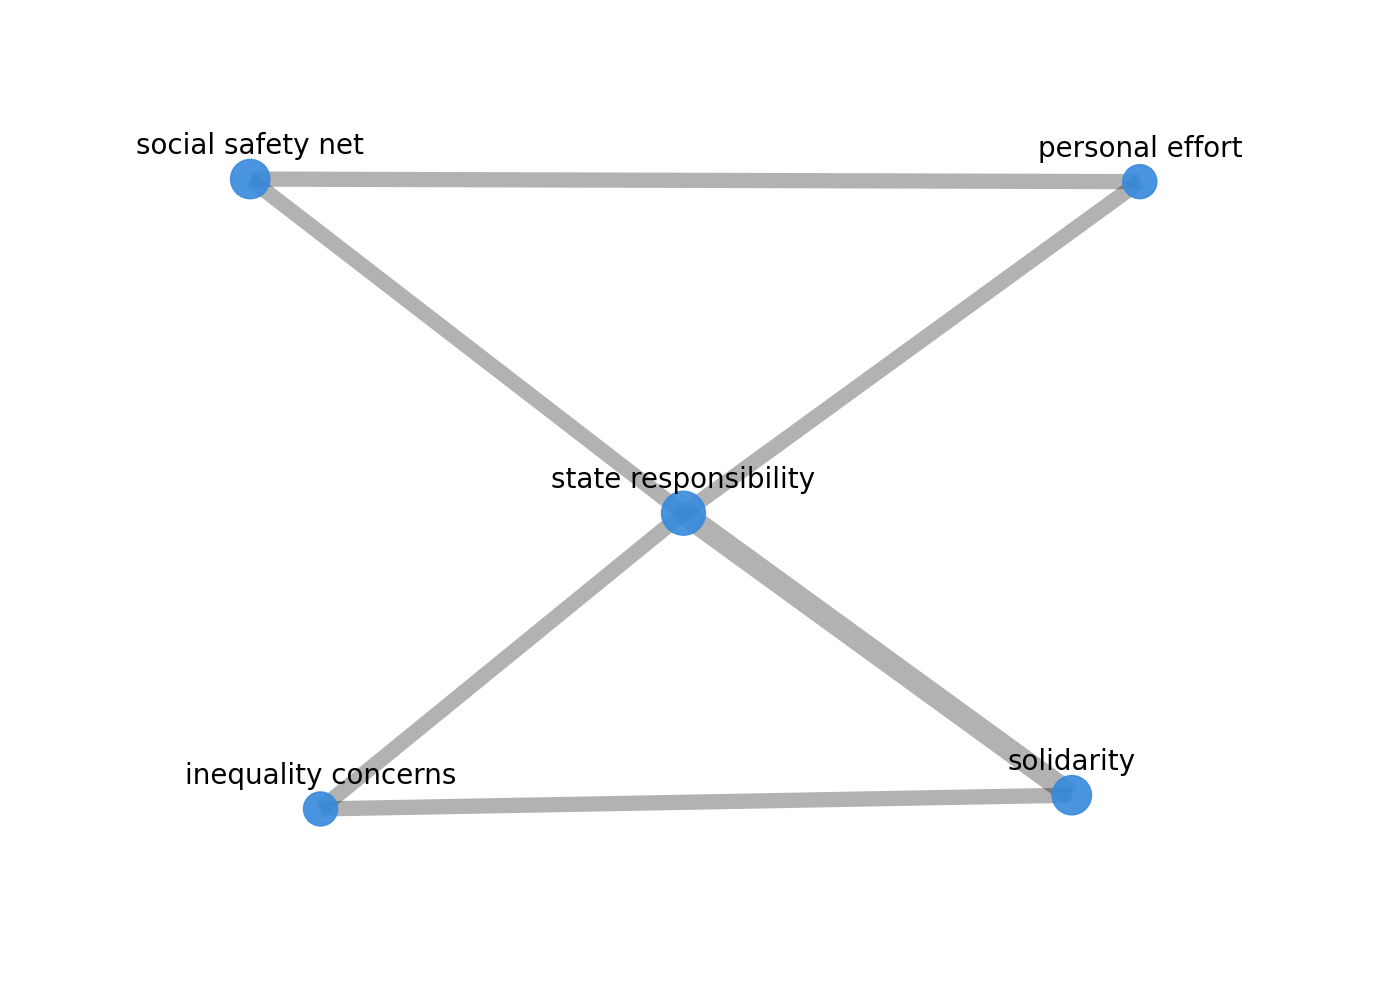

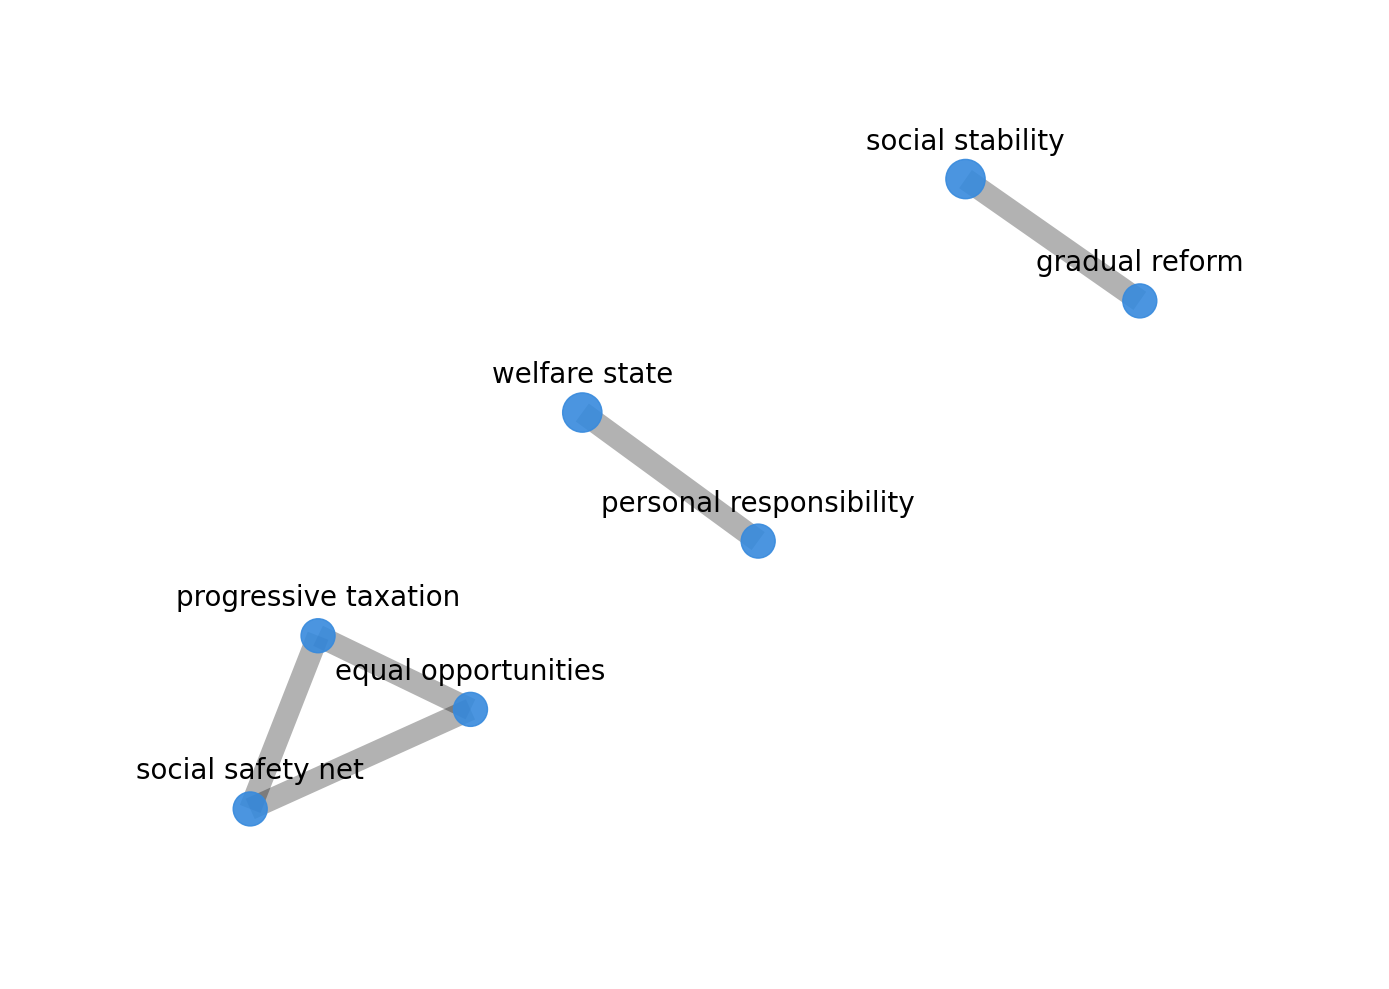

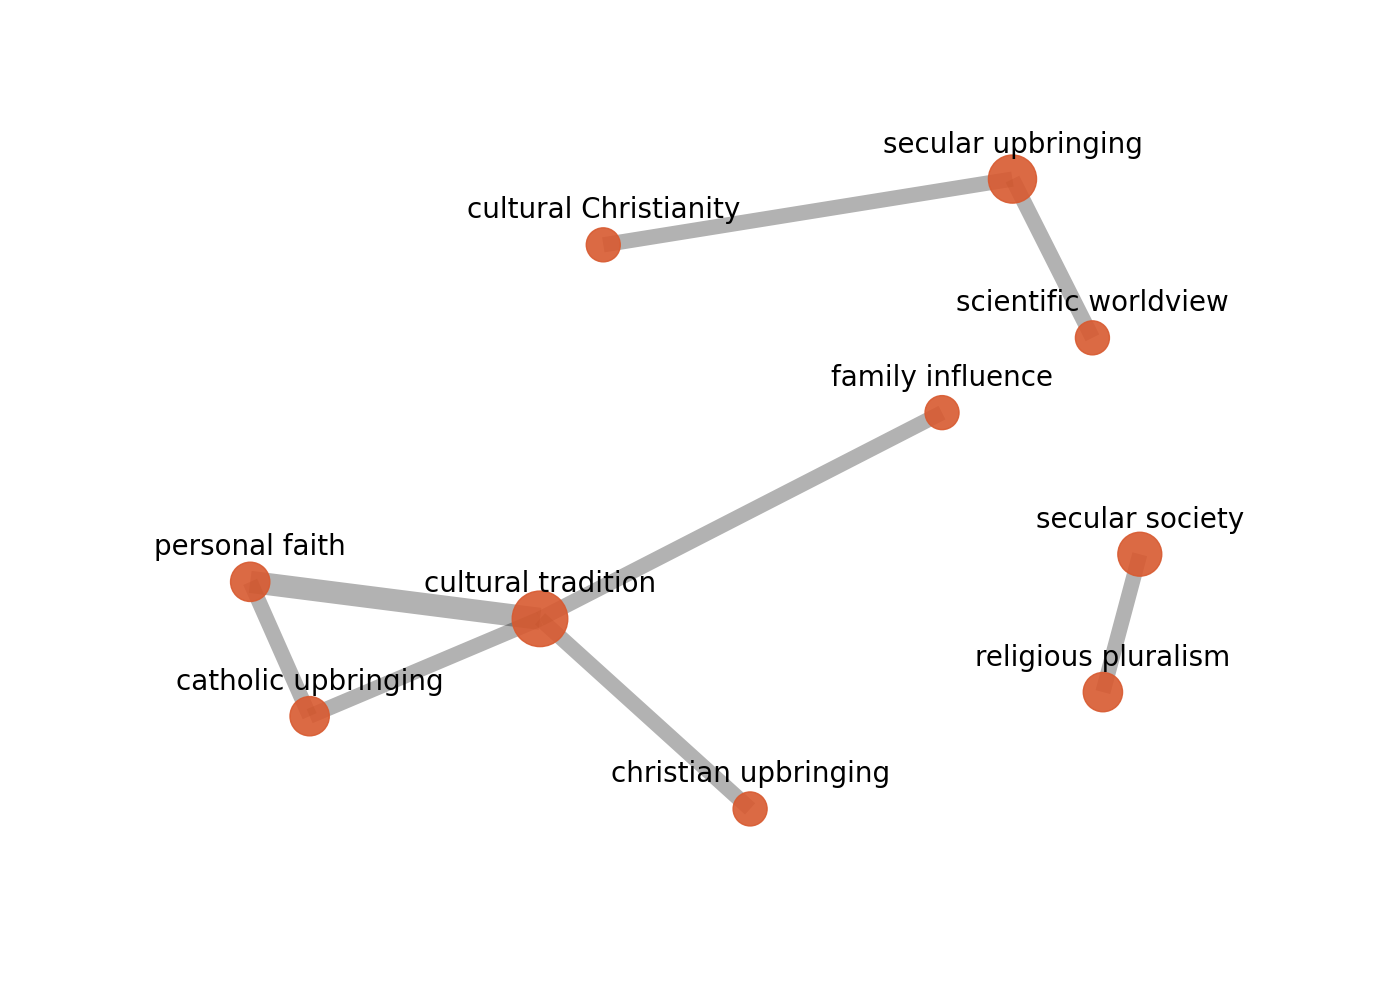

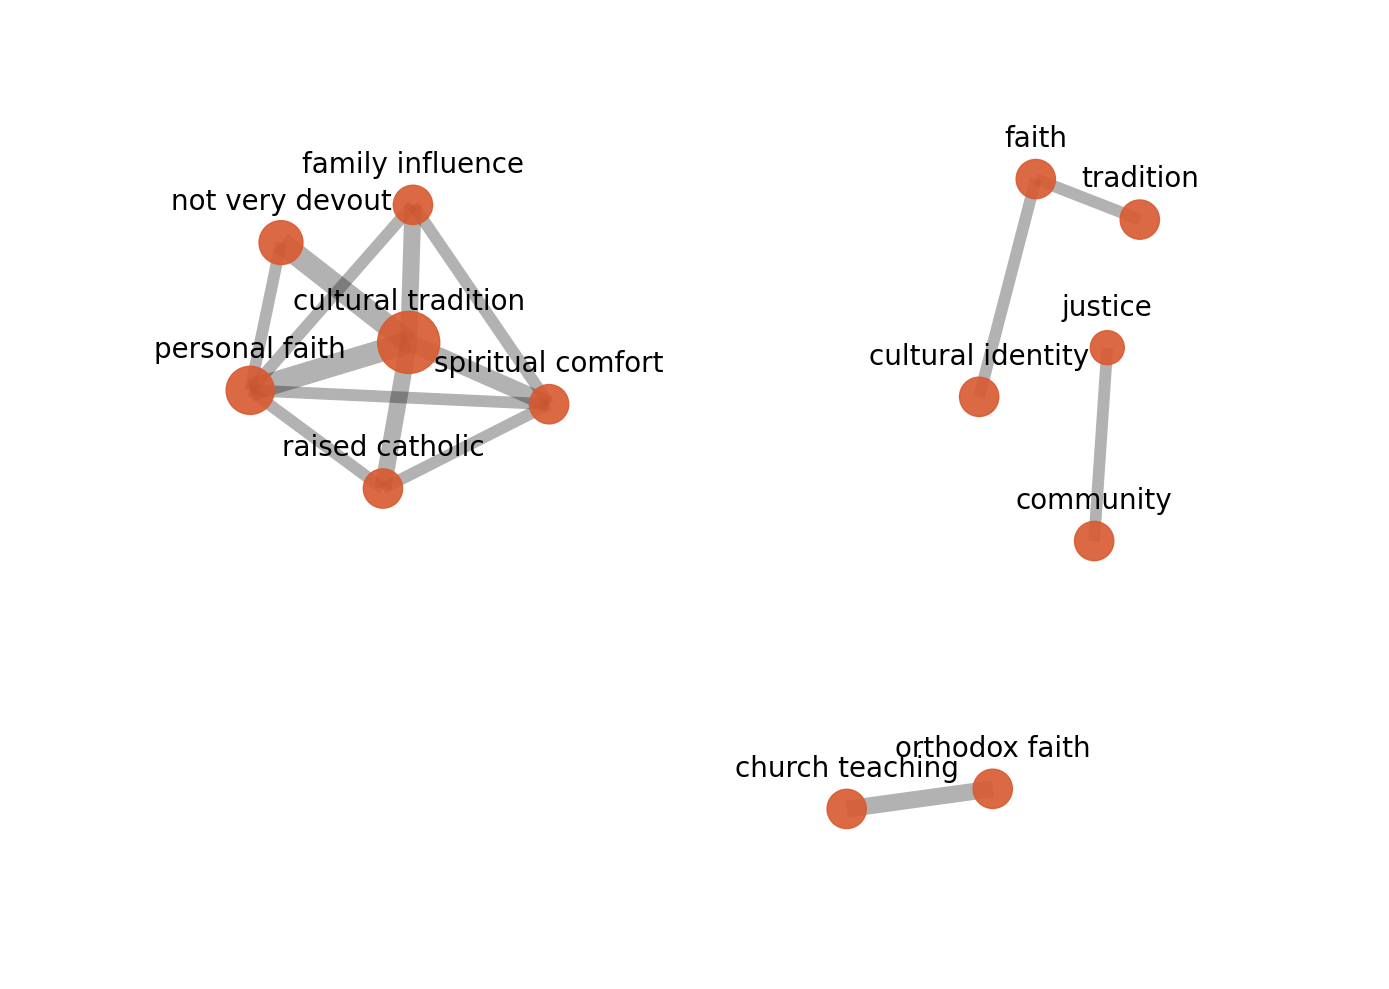

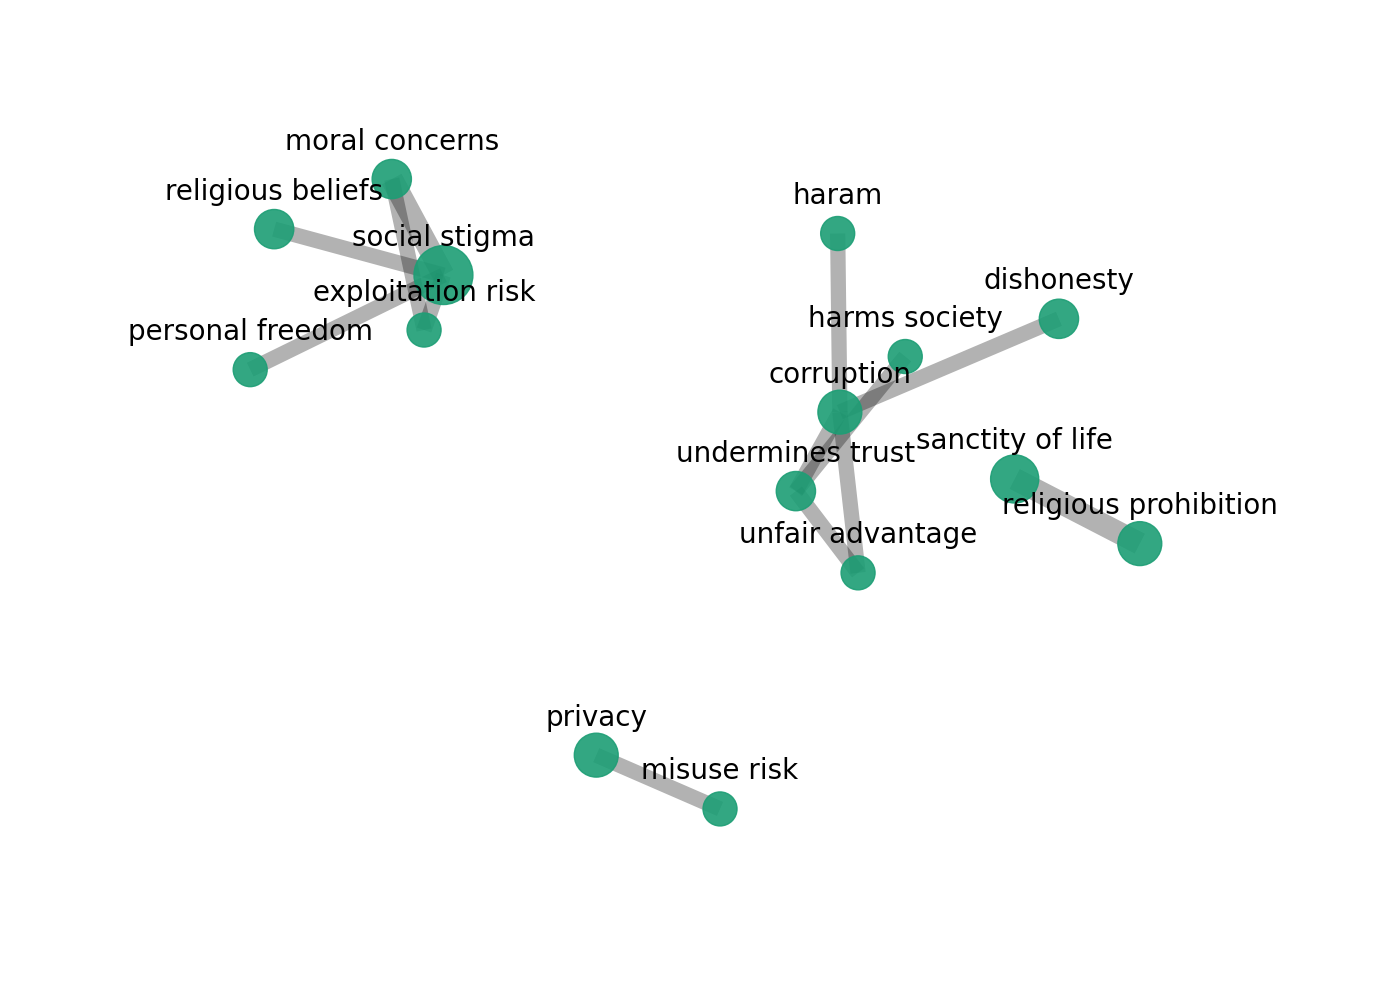

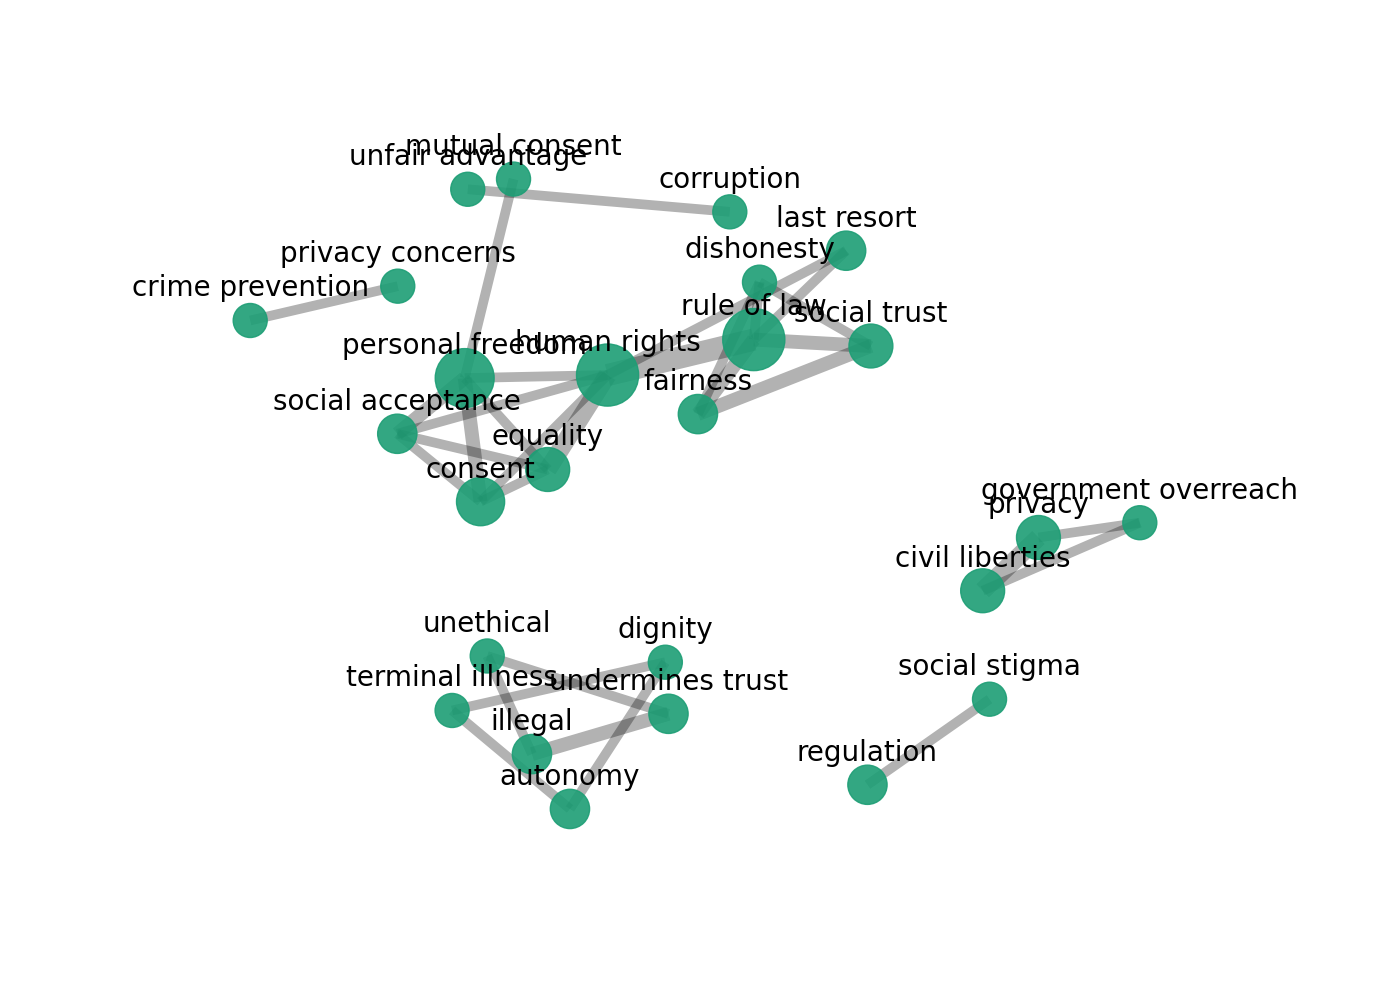

In [20]:
# Color mapping for each domain (used for consistent visualization across plots)
domain_colors = {
    "Economic": "#378ADD",   # blue
    "Religious": "#D85A30",  # orange
    "Ethical": "#1D9E75"     # green
}

# Model-specific keyword/node position adjustments for LOW condition
# Each entry maps:
#   domain -> {keyword -> (x_shift, y_shift)}
if MODEL_NAME == "GLM-5":

    low_adjustments = {
        "Economic": {
            "future generations": (-0.1, 0)
        },
        "Religious": {
            "soul immortality": (0, 0.5),
            "faith": (0, -0.2),
            "spirituality": (0.1, 0.1),
            "tradition": (-0.1, -0.1),
            "church": (-0.1, 0.1)
        }
    }

    # Model-specific keyword/node position adjustments for HIGH condition
    high_adjustments = {
        "Economic": {
            "future generations": (0.5, 0)
        },
        "Religious": {
            "devotion": (0.1, 0.1),
            "blessings": (0.1, -0.1),
            "karma": (0.8, 0.2),
            "spirituality": (0.1, 0),
            "judgment": (0.8, 0)
        }
    }

elif MODEL_NAME == "GPT-5.1":

    low_adjustments = {
        "Economic": {
            "inequality concerns": (0.1, 0.1),
        },
        "Religious": {
            "catholic upbringing": (0.2, 0),
            "scientific worldview": (-0.4, 0),
            "religious pluralism": (-0.1, 0)
        }
    }

    high_adjustments = {
        "Economic": {
            "equal opportunities": (0.5, -0.1),
            "progressive taxation": (0.7, 0.1),
            "social safety net": (0.5, 0)
        },
        "Religious": {
            "cultural identity": (-0.25, 0),
            "spiritual comfort": (0.2, -0.1),
            "cultural tradition": (0.15, 0),
            "not very devout": (-0.2, -0.05),
            "family influence": (0.3, 0.1),
            "personal faith": (0, -0.05)
        }
    }

elif MODEL_NAME == "Mistral Large 3":

    low_adjustments = {
        "Economic": {
            "social justice": (-0.8, -0.3),
            "moderate inequality": (-0.8, -0.3),
            "state support": (-0.3, 0)
        },
        "Religious": {
            "Christianity": (-0.4, -0.25),
            "social order": (-0.2, 0),
            "secular society": (-0.2, 0),
            "personal spirituality": (-0.2, -0.05),
            "cultural Christianity": (-0.8, -0.6),
            "low church attendance": (-1.7, -0.35),
            "ancestor veneration": (0.1, 0)
        }
    }

    high_adjustments = {
        "Economic": {
            "fairness": (0.1, 0.2)
        },
        "Religious": {
            "family": (-0.2, -0.2),
            "tradition": (0, 0.25),
            "faith": (0.2, 0),
            "Catholicism": (0.1, -0.05),
            "community": (-0.2, 0),
            "harmony": (-0.6, 0),
            "daily life": (-0.4, 0),
            "daily devotion": (-0.2, 0.2),
            "tolerance": (0.7, 0)
        }
    }

# Iterate over all domains and generate plots for both conditions
for domain, res in all_results.items():

    # Select consistent color for this domain's visualization
    color = domain_colors[domain]

    # Plot LOW condition graph with domain color and optional node adjustments
    plot_graph(
        res["low"]["graph"],
        node_color=color,
        adjustments=low_adjustments.get(domain)
    )

    # Plot HIGH condition graph with domain color and optional node adjustments
    plot_graph(
        res["high"]["graph"],
        node_color=color,
        adjustments=high_adjustments.get(domain)
    )